# CNN Concepts and Test Plan

This notebook uses a **convolutional neural network (CNN)** to classify **MNIST** digits (classic dataset of a handwritten digit images). A CNN applies small learnable filters in a **sliding-window** fashion across the image, which helps the model detect local features like edges or strokes. The same filter is reused over the whole image, so the network learns spatial patterns efficiently.
\
*Pay attention at ["padding" and "stride"](https://d2l.ai/chapter_convolutional-neural-networks/padding-and-strides.html) parameters of convolutional layers, as they affect the output size and the amount of spatial information retained.*
\
*Here we have a sliding-window size of 3x3, so for top-left pixel -1 pixel will be outside of the image, if padding=1 is not set it will lead to image degradation (size will shrink 1px each layer)*

In this model, the first convolutional layer produces 16 filters. These filters typically learn simple primitives such as small horizontal lines, vertical strokes, or short curves. For example, one filter might respond strongly to a thin vertical line in the center, while another responds to a small diagonal edge.

The second convolutional layer produces 32 filters. Because it receives 16 feature maps from the first layer, it can combine simpler primitives into more complex features, such as loops, corners, digit-specific shapes, or groupings of strokes. In other words, the first layer detects basic visual elements, and the second layer assembles them into richer patterns.

Pooling is used after convolution to reduce spatial size and keep the most important activations. Max pooling takes the strongest response from each local region, which helps the model become less sensitive to small translations and reduces computation.

Test cases in this notebook:
- Evaluate the model on 3 random images from the MNIST dataset.
- Use the interactive hand-drawing canvas to draw digits and see live predictions.

> Note: if there is an issue with the latest code block (canvas rendering), enable IPyWidgets support in VS Code settings. Open Settings, search for `Jupyter: Widget Script Sources`, and ensure `jsdelivr.com` or `unpkg.com` is included. This allows VS Code to download the `ipycanvas` JavaScript library required for rendering.

In [ ]:
pip install torchvision ipycanvas ipywidgets

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Pipeline: Data Loading & Normalization
# MNIST images are 28x28 grayscale pixels (1 channel)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and Std for MNIST
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)



In [ ]:
# 2. Architecture: The CNN
class MNISTConvNet(nn.Module):
    def __init__(self):
        super(MNISTConvNet, self).__init__()
        # Input: 1 channel (gray). Output: 16 filters.
        # kernel_size: 3x3, (sliding window). Stride 1 (move 1 pixel at a time).
        # padding: 1 (as sliding window 3x3 with center at 0:0 would go out of bounds, so we add 1 pixel of padding around the image).
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        # After convolution we shrink the image by 2 as we will now opperate by "bigger" features (i.e. lines/circles - not points).
        self.pool = nn.MaxPool2d(2, 2) # Divides dimensions by 2
        
        # Second convolutional layer:
        # Input: 16 channels. Output: 32 filters.
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Geometry Math: 
        # Start 28x28 -> Pool1 -> 14x14 -> Pool2 -> 7x7
        # Final shape: 32 channels * 7 * 7 pixels
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes (digits 0-9)
        
        # We do not have Softmax at the end because CrossEntropyLoss 
        # in PyTorch combines LogSoftmax and NLLLoss, so it expects raw logits.
        # (basically "backward" also does "forward", so even so that our arch has softmax in fact it's applied outside)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        
        x = x.view(-1, 32 * 7 * 7) # Flattening
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x



In [4]:
# 3. Training Setup
model = MNISTConvNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 4. Single Epoch Training Loop
model.train()
for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    
    if batch_idx % 100 == 0:
        print(f"Batch {batch_idx}: Loss {loss.item():.4f}")

Batch 0: Loss 2.3134
Batch 100: Loss 0.2444
Batch 200: Loss 0.1325
Batch 300: Loss 0.0840
Batch 400: Loss 0.0483
Batch 500: Loss 0.0301
Batch 600: Loss 0.0636
Batch 700: Loss 0.2470
Batch 800: Loss 0.0504
Batch 900: Loss 0.0566



Example 1 (Label: 7):
Prediction Vector (10): [ -1.1428281   0.8878783   5.590434    2.1231692  -4.505751   -7.0673943
 -11.119519   10.984151    0.8594853   1.749289 ]
Predicted Class: 7

Example 2 (Label: 7):
Prediction Vector (10): [  0.02119781  -0.76166403   2.7390552    0.960407    -1.1152823
  -6.3437605  -11.224226    12.617723    -2.112335     3.68613   ]
Predicted Class: 7

Example 3 (Label: 5):
Prediction Vector (10): [-2.6017056  -6.5681386  -6.247059    0.7498034  -3.0427163  10.31943
 -3.8915548  -1.9227     -0.40520063  1.6209841 ]
Predicted Class: 5


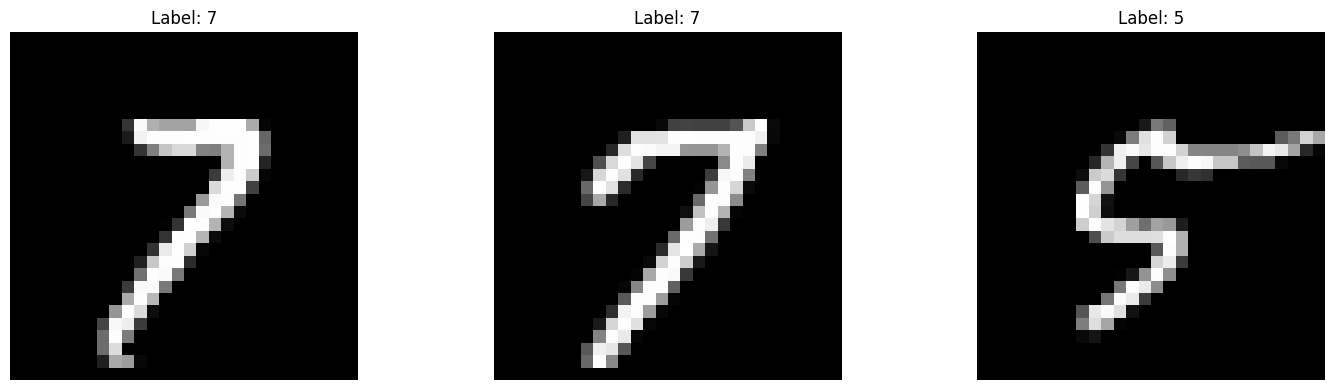

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

# 5. Visualization: Display 3 random examples with predictions
model.eval()

# Get 3 random indices
random_indices = random.sample(range(len(train_dataset)), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (ax, sample_idx) in enumerate(zip(axes, random_indices)):
    # Get image and label
    image, label = train_dataset[sample_idx]
    
    # Convert to numpy for display
    image_display = image.squeeze().numpy()
    
    # Get model prediction
    with torch.no_grad():
        image_batch = image.unsqueeze(0)  # Add batch dimension
        prediction = model(image_batch)
        prediction_vector = prediction[0].cpu().numpy()
    
    # Plot image
    ax.imshow(image_display, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
    
    # Print prediction vector
    print(f"\nExample {idx + 1} (Label: {label}):")
    print(f"Prediction Vector (10): {prediction_vector}")
    print(f"Predicted Class: {np.argmax(prediction_vector)}")

plt.tight_layout()
plt.show()

In [7]:
from ipycanvas import Canvas, hold_canvas
from ipywidgets import Button, VBox, HBox, Output, Layout
import io
import traceback

# 6. Interactive Drawing Canvas
# Create canvas
canvas = Canvas(width=200, height=200, background_color='white', sync_image_data=True)
canvas.fill_style = 'black'
canvas.stroke_style = 'black'
canvas.line_width = 12
canvas.line_cap = 'round'
canvas.line_join = 'round'
canvas.fill_style = "white"
canvas.fill_rect(0, 0, canvas.width, canvas.height)


# Track drawing state
is_drawing = False
last_x = 0
last_y = 0

def on_mouse_down(x, y):
    global is_drawing, last_x, last_y
    is_drawing = True
    last_x = x
    last_y = y

def on_mouse_move(x, y):
    global is_drawing, last_x, last_y
    if is_drawing:
        with hold_canvas(canvas):
            canvas.stroke_line(last_x, last_y, x, y)
        last_x = x
        last_y = y

def on_mouse_up(x, y):
    global is_drawing
    is_drawing = False

# Attach mouse events
canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

# Output area for predictions
output_area = Output()

# Clear button
def on_clear_clicked(button):
    canvas.clear()
    canvas.fill_style = "white"
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    output_area.clear_output()

clear_button = Button(description='Clear', button_style='warning')
clear_button.on_click(on_clear_clicked)

# Check button
def on_check_clicked(button):
    output_area.clear_output()

    try:
        with output_area:
            print("running...")

        img_data = canvas.get_image_data()

        rgba = np.array(img_data)

        gray = rgba[:, :, 0]

        img_pil = Image.fromarray(gray).convert("L")
        img_pil = img_pil.resize((28, 28))

        img_array = np.array(img_pil, dtype=np.float32) / 255.0
        img_array = 1.0 - img_array

        img_tensor = torch.from_numpy(img_array)\
            .unsqueeze(0)\
            .unsqueeze(0)

        img_tensor = (img_tensor - 0.1307) / 0.3081

        model.eval()

        with torch.no_grad():
            prediction = model(img_tensor)
            probs = torch.softmax(prediction, dim=1)[0]
            probs_np = probs.cpu().numpy()

        with output_area:
            print(f"\nPrediction: {np.argmax(probs_np)}\n")

            for i, p in enumerate(probs_np):
                print(f"{i}: {p:.4f}")

    except Exception:
        with output_area:
            traceback.print_exc()

check_button = Button(description='Check', button_style='success')
check_button.on_click(on_check_clicked)

# Display interface
print("Draw a digit (0-9) on the canvas below:")

canvas.layout = Layout(
    width='200px',
    height='200px',
    border='1px solid black'
)
controls = HBox(
    [check_button, clear_button],
    layout=Layout(
        width='200px',
        justify_content='space-between'
    )
)
VBox([canvas, controls, output_area])


Draw a digit (0-9) on the canvas below:
